# Skill-Based Job Role Predictor
## Notebook 1: Exploratory Data Analysis (EDA) & Data Cleaning

In this notebook we explore and clean the raw dataset before building the model.

**Goals:**
- Understand the structure of the data
- Identify and fix data quality issues (missing values, broken column names, class imbalance)
- Explore skill and experience distribution across job roles
- Save a cleaned dataset for model training

## 1. Loading the Data
Loading the dataset and inspecting its basic structure: shape, column types, and first rows.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/hh_jobs_dataset.csv')

print('Dataset shape:', df.shape)
print()
print('Columns:')
print(df.columns.tolist())

Dataset shape: (570, 70)

Columns:
['job_role', 'title', 'skills', 'skills_count', 'experience', 'salary', 'company', 'city', 'employment', 'url', 'skill_SQL', 'skill_Английский\xa0—_B2_—_Средне-продвинутый', 'skill_Английский_язык', 'skill_Python', 'skill_Docker', 'skill_Git', 'skill_Kubernetes', 'skill_PostgreSQL', 'skill_CI_CD', 'skill_JavaScript', 'skill_Английский\xa0—_B1_—_Средний', 'skill_Бизнес-анализ', 'skill_Английский\xa0—_C1_—_Продвинутый', 'skill_Аналитическое_мышление', 'skill_REST_API', 'skill_TypeScript', 'skill_Linux', 'skill_React', 'skill_Figma', 'skill_Деловая_коммуникация', 'skill_BPMN', 'skill_Java', 'skill_API', 'skill_UML', 'skill_Redis', 'skill_MySQL', 'skill_Agile', 'skill_Power_BI', 'skill_UX', 'skill_Postman', 'skill_HTML', 'skill_Atlassian_Jira', 'skill_UI', 'skill_DevOps', 'skill_PHP', 'skill_Grafana', 'skill_Adobe_Photoshop', 'skill_Разработка_технических_заданий', 'skill_Русский\xa0—_C2_—_В_совершенстве', 'skill_MS_Excel', 'skill_User_Story', 'skill_REST

## 2. First Look at the Data
We inspect the first few rows and data types to understand what we are working with.

In [33]:
df.head()

,job_role,title,skills,skills_count,experience,salary,company,city,employment,url,...,skill_Русский —_C1_—_Продвинутый,skill_Angular,skill_Apache_Kafka,skill_Laravel,skill_Adobe_Illustrator,skill_Анализ_данных,skill_Gitlab,skill_Golang,skill_Node_js,skill_Системный_анализ
0,Data Scientist,NaN,Python; Математическая статистика; Исследовате...,4,3–6 лет,NaN,ТООМикрофинансовая организация ФРИДОМ ФИНАНС К...,NaN,NaN,https://hh.ru/vacancy/131986700,...,0,0,0,0,0,0,0,0,0,0
1,Data Scientist,NaN,SQL; Анализ данных; Базы данных,3,3–6 лет,NaN,АОСтраховая компания Freedom Insurance,NaN,NaN,https://hh.ru/vacancy/131781668,...,0,0,0,0,0,1,0,0,0,0
2,Data Scientist,NaN,Python; SQL; Numpy; pandas; Scikit-learn; CatB...,12,1–3 года,NaN,АОKMF Банк,NaN,NaN,https://hh.ru/vacancy/132560452,...,0,0,0,0,0,0,0,0,0,0
3,Data Scientist,NaN,Python; SQL; Scikit-learn; Deep Learning; XGBo...,7,3–6 лет,NaN,АОAlatau City Bank,NaN,NaN,https://hh.ru/vacancy/131990623,...,0,0,0,0,0,0,0,0,0,0
4,Data Scientist,NaN,Английский — B2 — Средне-продвинутый,1,3–6 лет,NaN,"ТООEpam Kazakhstan (Эпам Казахстан),ТОО",NaN,NaN,https://hh.ru/vacancy/131826592,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df.dtypes

job_role                   object
title                     float64
skills                     object
skills_count                int64
experience                 object
                           ...   
skill_Анализ_данных         int64
skill_Gitlab                int64
skill_Golang                int64
skill_Node_js               int64
skill_Системный_анализ      int64
Length: 70, dtype: object

## 3. Missing Values
We check which columns have missing values. Columns that are entirely empty are useless for modeling and should be dropped.

In [35]:
missing = df.isnull().sum()
print(missing[missing > 0])

title         570
salary        570
city          570
employment    570
dtype: int64


As we can see, the columns `title`, `salary`, `city`, and `employment` are entirely empty (570 nulls out of 570 rows).
These columns carry no information and will be dropped during preprocessing.

The columns `url` and `company` are not useful for prediction either. They are identifiers, not features.

In [36]:
df = df.drop(columns=['title', 'salary', 'city', 'employment', 'url', 'company'])
print('Shape after dropping useless columns:', df.shape)

Shape after dropping useless columns: (570, 64)


## 4. Class Distribution
We check how many samples exist per job role. This is our target variable.
A large imbalance between classes can cause the model to ignore minority classes.

In [37]:
class_counts = df['job_role'].value_counts()
print(class_counts)

job_role
Business Analyst             75
Frontend Developer           73
Backend Developer            71
Product Manager              67
UX Designer                  67
QA Engineer                  67
DevOps Engineer              61
Data Analyst                 54
Machine Learning Engineer    27
Data Scientist                8
Name: count, dtype: int64


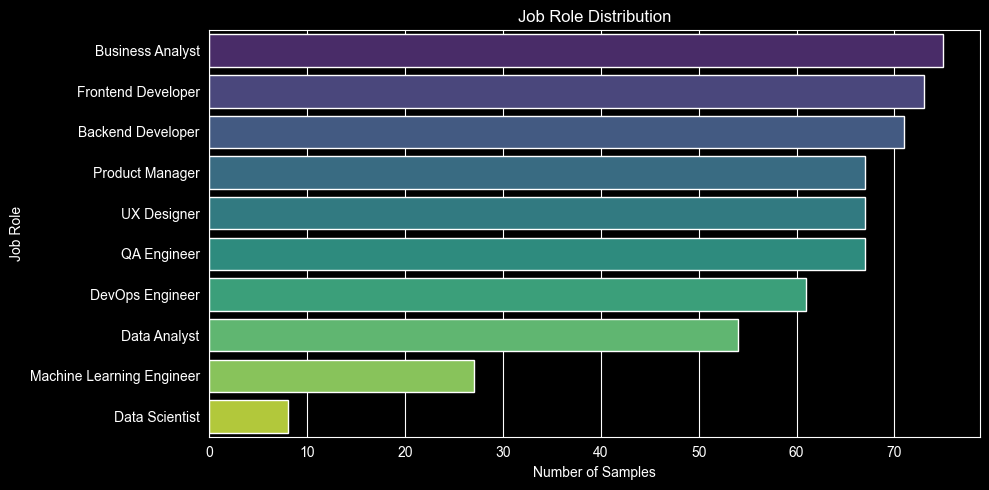

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Job Role Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Job Role')
plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced. `Data Scientist` has only 8 samples while `Business Analyst` has 75.
**How we handle this:** We will use `class_weight='balanced'` in both KNN and SVM models.
This tells the model to pay more attention to minority classes during training.

## 5. Experience Distribution
We look at how experience levels are distributed across the dataset.
This column will later be encoded as a number for the model.

In [39]:
exp_counts = df['experience'].value_counts()
print(exp_counts)

experience
3–6 лет         302
1–3 года        198
более 6 лет      48
не требуется     22
Name: count, dtype: int64


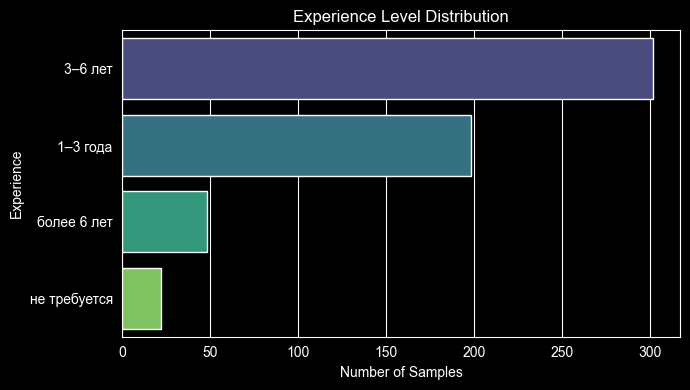

In [40]:
plt.figure(figsize=(7, 4))
sns.barplot(x=exp_counts.values, y=exp_counts.index, hue=exp_counts.index, palette='viridis', legend=False)
plt.title('Experience Level Distribution')
plt.xlabel('Number of Samples')
plt.ylabel('Experience')
plt.tight_layout()
plt.show()

**Observation:** Most job listings require 3–6 years of experience.
Only 22 listings require no experience at all.

As  `experience` column is a text label, we convert it to an ordinal number so the model can use it.
Higher number means more experience required.

In [41]:
experience_map = {
    'не требуется': 0,
    '1–3 года': 1,
    '3–6 лет': 2,
    'более 6 лет': 3
}

df['experience'] = df['experience'].map(experience_map)
print(df['experience'].value_counts())

experience
2    302
1    198
3     48
0     22
Name: count, dtype: int64


## 6. Top Skills Per Role
We look at the most common skills for each job role.
This helps us understand which skills are strong indicators of a particular role and directly demonstrates the value of our binary skill features for classification.

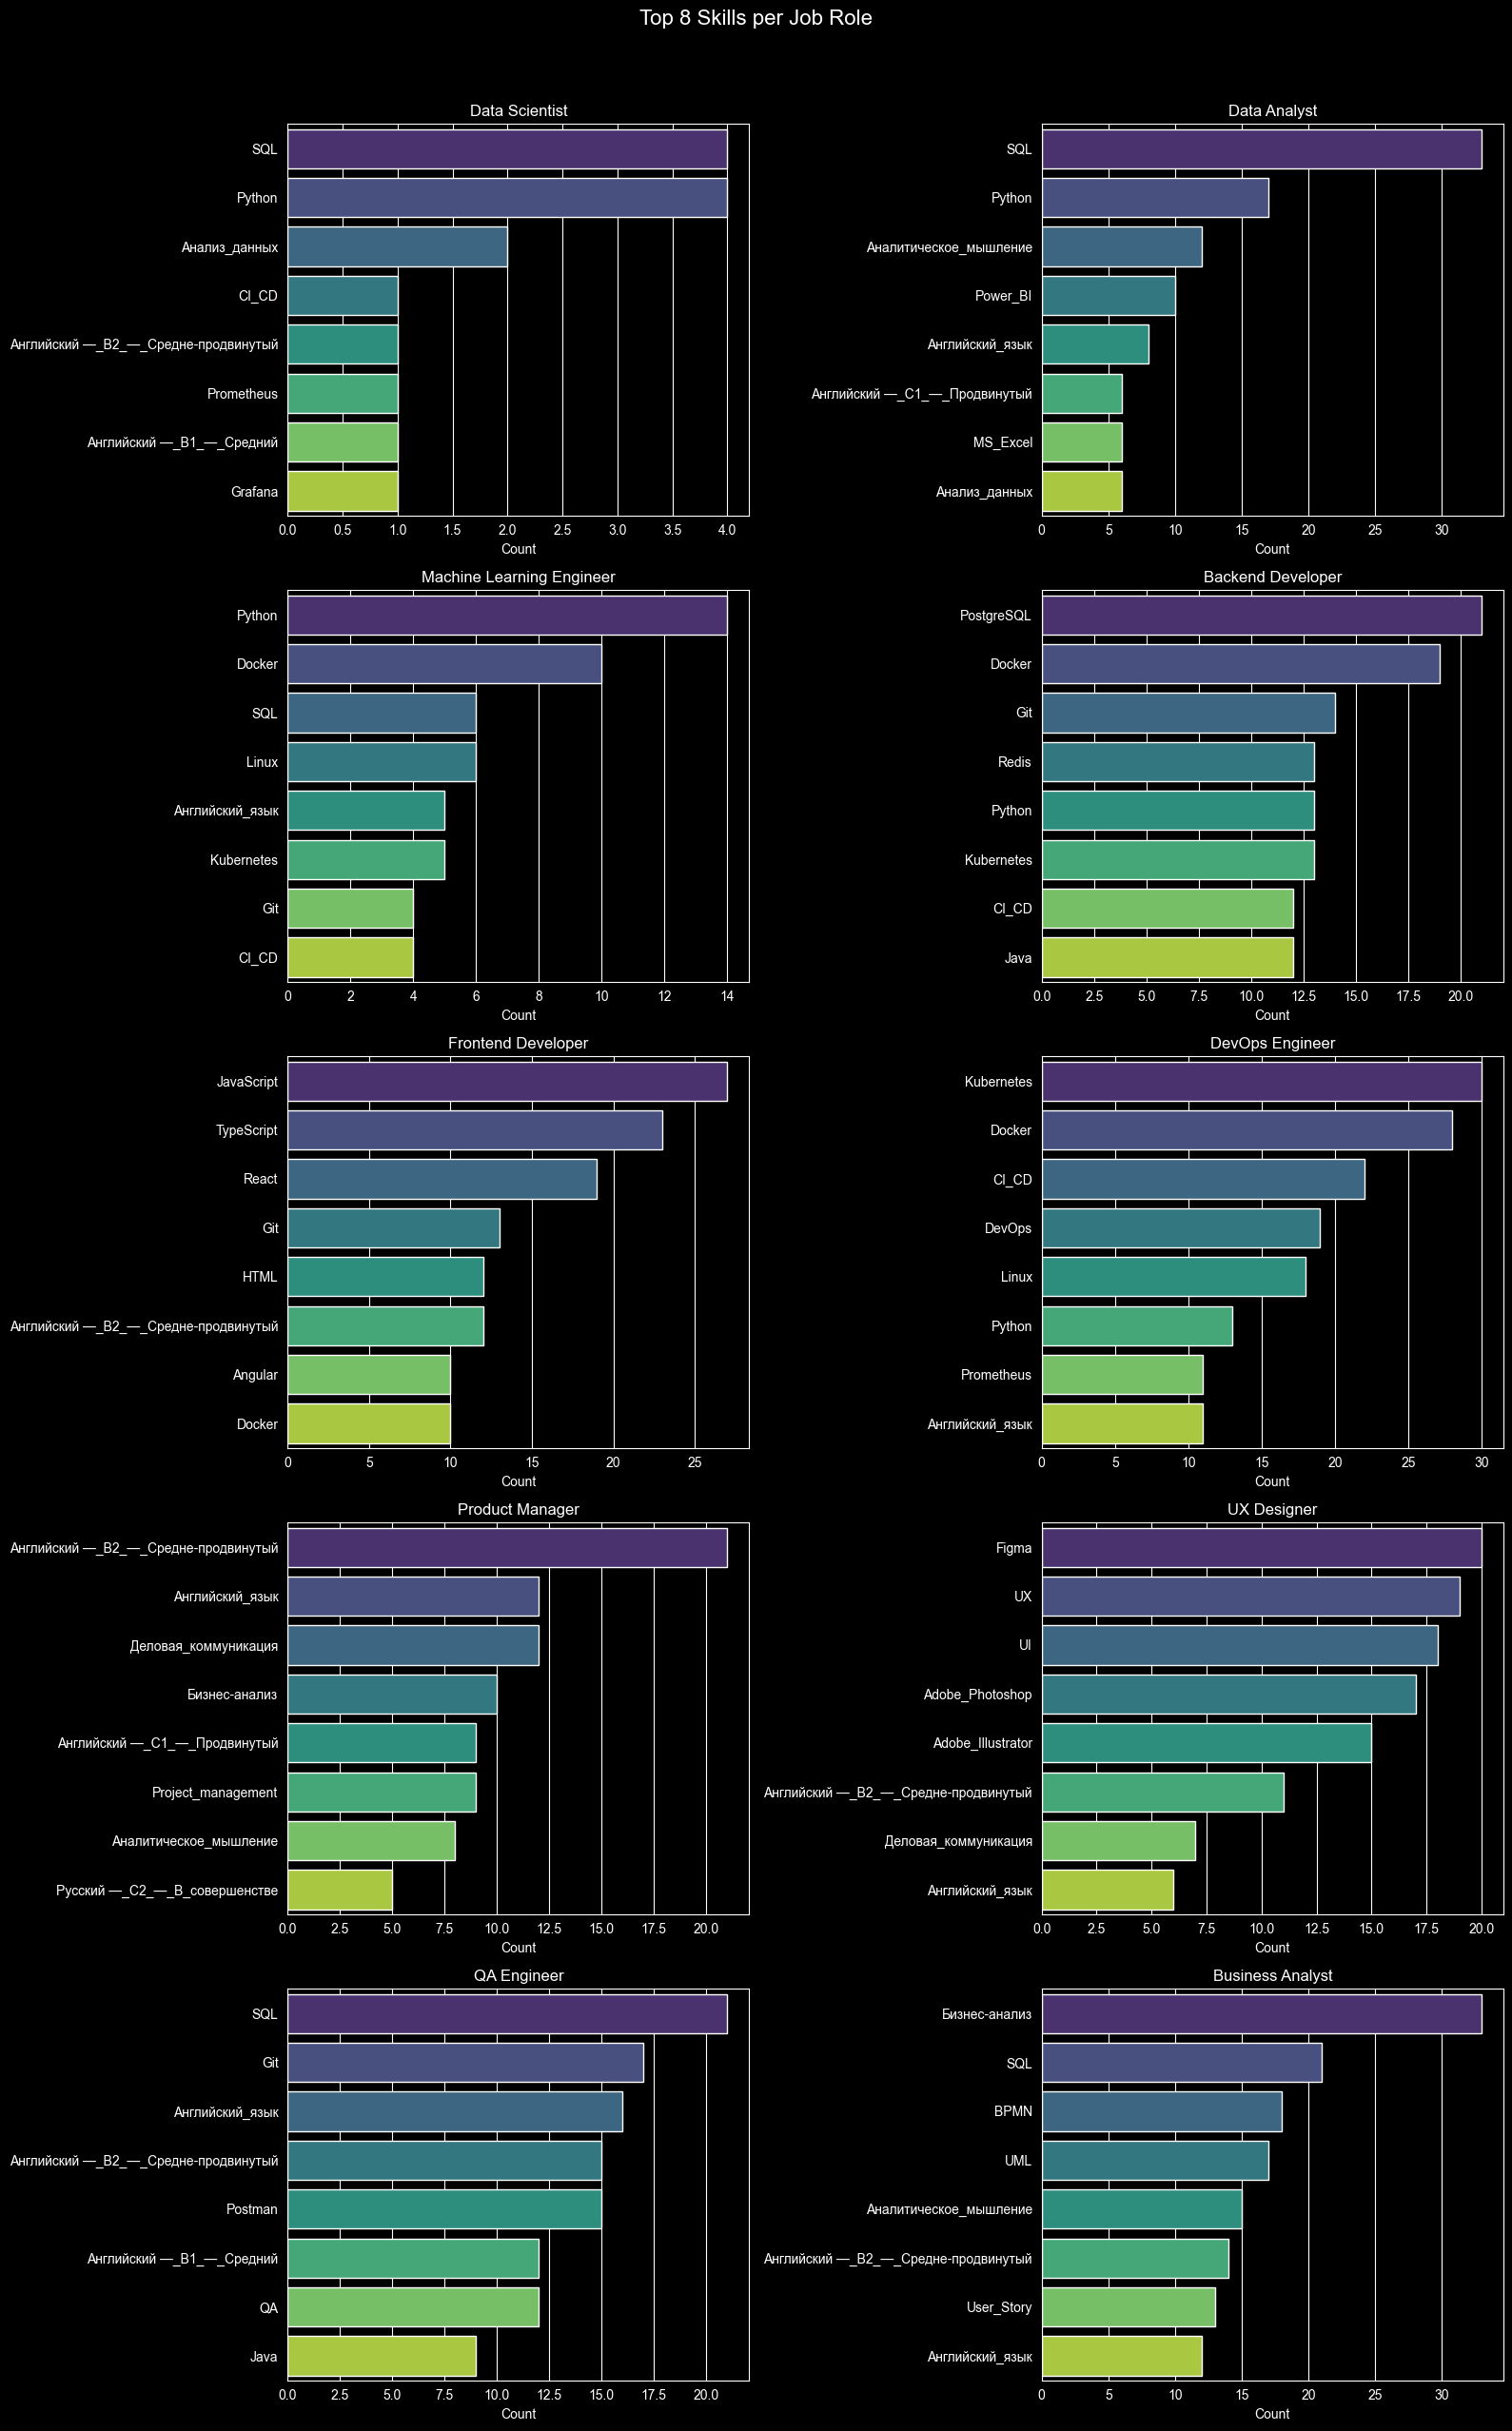

In [42]:
import math

skill_cols = [c for c in df.columns if c.startswith('skill_')]

roles = df['job_role'].unique()
n_roles = len(roles)

cols = 2
rows = math.ceil(n_roles / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))

axes = axes.flatten()

for i, role in enumerate(roles):
    role_df = df[df['job_role'] == role][skill_cols]

    top_skills = role_df.sum().sort_values(ascending=False).head(8)
    top_skills.index = [s.replace('skill_', '') for s in top_skills.index]

    sns.barplot(
        x=top_skills.values,
        y=top_skills.index,
        hue=top_skills.index,
        palette='viridis',
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(role)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 8 Skills per Job Role', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. Fixing Column Names
Some skill column names contain `\xa0` (non-breaking space character) due to encoding issues during scraping.
We clean all column names by replacing `\xa0` with an empty string.

In [43]:
df.columns = [col.replace('\xa0', '') for col in df.columns]
print('Columns cleaned. Sample skill columns:')
print([c for c in df.columns if c.startswith('skill_')][:5])

Columns cleaned. Sample skill columns:
['skill_SQL', 'skill_Английский—_B2_—_Средне-продвинутый', 'skill_Английский_язык', 'skill_Python', 'skill_Docker']


## 8. Merging similar classes
`Data Scientist` has only 8 samples in the whole dataset — too few to learn from.
`Machine Learning Engineer` is a very similar role with 27 samples.
We combine them into one class `Data Science / ML` so the model has more data to learn from.


In [47]:
df['job_role'] = df['job_role'].replace({
    'Data Scientist': 'Data Science / ML',
    'Machine Learning Engineer': 'Data Science / ML'
})

print('Updated class distribution:')
print(df['job_role'].value_counts())

Updated class distribution:
job_role
Business Analyst      75
Frontend Developer    73
Backend Developer     71
Product Manager       67
UX Designer           67
QA Engineer           67
DevOps Engineer       61
Data Analyst          54
Data Science / ML     35
Name: count, dtype: int64


## 8. Final Dataset Check
We verify the cleaned dataset looks correct before saving.

In [48]:
print('Final shape:', df.shape)
print()
print('Missing values:', df.isnull().sum().sum())
print()
df.head()

Final shape: (570, 64)

Missing values: 0



,job_role,skills,skills_count,experience,skill_SQL,skill_Английский—_B2_—_Средне-продвинутый,skill_Английский_язык,skill_Python,skill_Docker,skill_Git,...,skill_Русский—_C1_—_Продвинутый,skill_Angular,skill_Apache_Kafka,skill_Laravel,skill_Adobe_Illustrator,skill_Анализ_данных,skill_Gitlab,skill_Golang,skill_Node_js,skill_Системный_анализ
0,Data Science / ML,Python; Математическая статистика; Исследовате...,4,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Data Science / ML,SQL; Анализ данных; Базы данных,3,2,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,Data Science / ML,Python; SQL; Numpy; pandas; Scikit-learn; CatB...,12,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,Data Science / ML,Python; SQL; Scikit-learn; Deep Learning; XGBo...,7,2,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Data Science / ML,Английский — B2 — Средне-продвинутый,1,2,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 9. Saving Cleaned Dataset
We save the cleaned dataset so `02_model.ipynb` can load it directly without repeating these steps.

In [49]:
df.to_csv('../data/cleaned_dataset.csv', index=False)
print('Cleaned dataset saved to data/cleaned_dataset.csv')

Cleaned dataset saved to data/cleaned_dataset.csv
